# GCMC basics with mcpy (Lennard-Jones)

Grand-canonical Monte Carlo (GCMC) samples configurations of a system that exchanges particles with a reservoir at fixed chemical potential $\mu$, volume $V$, and temperature $T$.
mcpy's loop is:

```
GrandCanonicalEnsemble.run(steps)
  └─ each step: MoveSelector picks a move (insertion / deletion / displacement ...)
       └─ move mutates the ASE Atoms in place
       └─ calculator returns the (optionally relaxed) energy
       └─ Metropolis / de Broglie acceptance; rejected moves are rolled back
```

Insertions and deletions are accepted with

$$p_\mathrm{ins} = \frac{V}{(N+1)\Lambda^3} e^{-\beta(\Delta E - \mu)}, \qquad
p_\mathrm{del} = \frac{N\Lambda^3}{V} e^{-\beta(\Delta E + \mu)}.$$

This notebook uses LJ units (the de Broglie wavelength $\Lambda = 1$) and cheap toy calculators, so every cell runs on a laptop CPU in seconds.
The same sampler has been validated against LAMMPS `fix gcmc`: see `benchmark/README.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms

from mcpy.cell import Cell
from mcpy.ensembles.grand_canonical_ensemble import GrandCanonicalEnsemble
from mcpy.moves import InsertionMove, DeletionMove, DisplacementMove, MoveSelector

## 1. Ideal gas: the exactly solvable check

With interactions switched off, the grand-canonical distribution of $N$ is a Poisson distribution with
$\langle N \rangle = V e^{\beta\mu} / \Lambda^3$.
If the sampler is correct we must recover it.

In [2]:
class ZeroCalc:
    """No interactions: the ideal gas."""
    def get_potential_energy(self, atoms):
        return 0.0

L, T, mu = 9.0, 2.0, -4.0
n_exact = L**3 * np.exp(mu / T)        # LJ units: beta = 1/T, Lambda = 1
print(f'analytic <N> = {n_exact:.2f}')

atoms = Atoms(cell=[L, L, L], pbc=True)
cell = Cell(atoms)
ms = MoveSelector([1, 1],
                  [InsertionMove(cell, species=['H'], seed=1),
                   DeletionMove(cell, species=['H'], seed=2)],
                  seed=3, n_moves=1)
g = GrandCanonicalEnsemble(atoms=atoms, cells=[cell], units_type='LJ',
                           calculator=ZeroCalc(), mu={'H': mu}, species=['H'],
                           temperature=T, move_selector=ms, random_seed=4,
                           traj_file=None, outfile=None)

n_trace = []
for _ in range(20_000):
    g.do_gcmc_step()
    n_trace.append(len(g.atoms))
n_trace = np.array(n_trace)
print(f'sampled  <N> = {n_trace[8000:].mean():.2f}')

analytic <N> = 98.66


sampled  <N> = 95.81


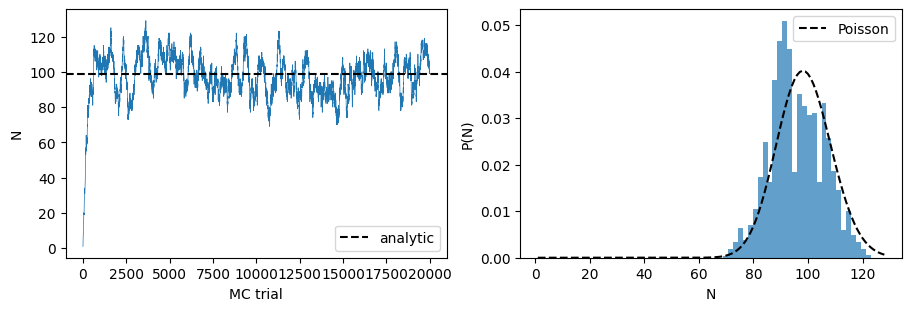

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
a1.plot(n_trace, lw=0.5)
a1.axhline(n_exact, color='k', ls='--', label='analytic')
a1.set(xlabel='MC trial', ylabel='N'); a1.legend()
a2.hist(n_trace[8000:], bins=30, density=True, alpha=0.7)
ns = np.arange(n_trace.min(), n_trace.max())
from scipy.stats import poisson
a2.plot(ns, poisson.pmf(ns, n_exact), 'k--', label='Poisson')
a2.set(xlabel='N', ylabel='P(N)'); a2.legend()
plt.show()

## 2. An interacting system

Now a truncated-and-shifted LJ fluid, with a displacement move added so configurations decorrelate faster.
Watch the acceptance ratios: they are the first thing to check when tuning a simulation.

acceptance per move (ins, del, disp): ['0.22', '0.19', '0.62']


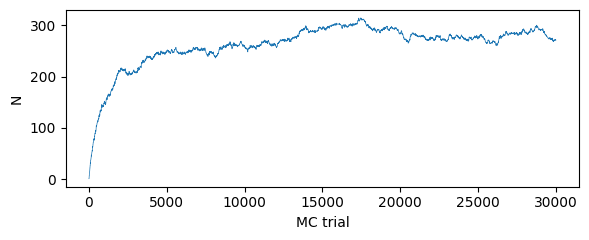

In [4]:
class LJCalc:
    """Vectorized truncated-and-shifted LJ, minimum image, sigma = eps = 1."""
    RC = 3.0
    E_SHIFT = 4.0 * (RC**-12 - RC**-6)
    def __init__(self, box):
        self.box = box
    def get_potential_energy(self, atoms):
        pos = atoms.positions
        if len(pos) < 2:
            return 0.0
        d = pos[:, None, :] - pos[None, :, :]
        d -= self.box * np.round(d / self.box)
        r2 = np.einsum('ijk,ijk->ij', d, d)[np.triu_indices(len(pos), k=1)]
        r2 = r2[r2 < self.RC**2]
        inv6 = 1.0 / r2**3
        return float(np.sum(4.0 * (inv6*inv6 - inv6) - self.E_SHIFT))

atoms = Atoms(cell=[L, L, L], pbc=True)
cell = Cell(atoms)
ms = MoveSelector([1, 1, 1],
                  [InsertionMove(cell, species=['H'], seed=11),
                   DeletionMove(cell, species=['H'], seed=12, min_atoms=1),
                   DisplacementMove(species=['H'], seed=13, max_displacement=0.3)],
                  seed=14, n_moves=1)
g = GrandCanonicalEnsemble(atoms=atoms, cells=[cell], units_type='LJ',
                           calculator=LJCalc(L), mu={'H': -2.4}, species=['H'],
                           temperature=T, move_selector=ms, random_seed=15,
                           traj_file=None, outfile=None)
trace = []
for _ in range(30_000):
    g.do_gcmc_step()
    trace.append(len(g.atoms))
print('acceptance per move (ins, del, disp):',
      [f'{r:.2f}' for r in ms.total_ratios()])
plt.figure(figsize=(6, 2.5))
plt.plot(trace, lw=0.5)
plt.xlabel('MC trial'); plt.ylabel('N'); plt.tight_layout(); plt.show()

The interacting fluid equilibrates to a higher density than the ideal gas at the same $\mu$ (net attraction).
The trace *is* the diagnostic: always confirm the plateau before trusting averages, and average only the stationary part.

**Where to go next**

* `molecular_gcmc.ipynb`: inserting whole molecules instead of atoms.
* `examples/gcmc.py` and `examples/gcmc_custom_cell.py`: production scripts with MACE potentials and surface insertion regions.
* `benchmark/README.md`: the LAMMPS cross-validation of exactly this sampler.